# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

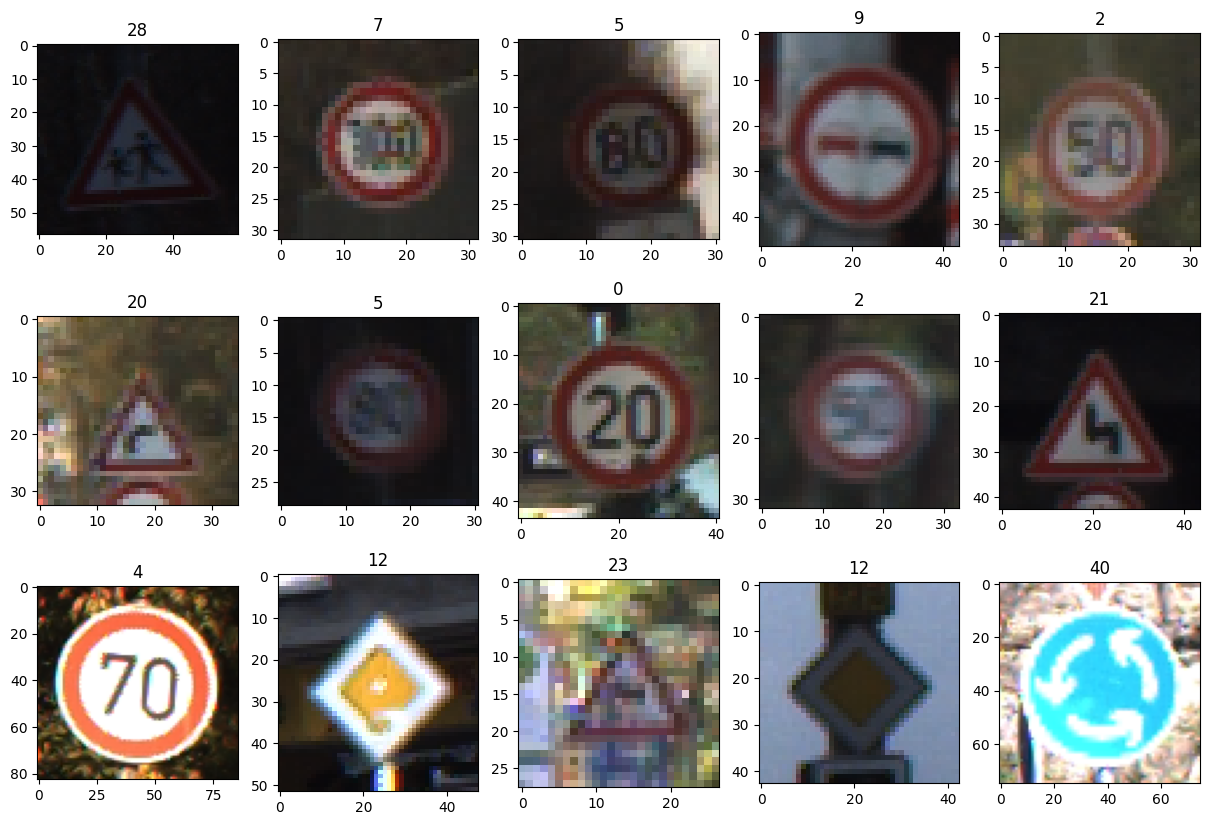

In [2]:
# Load the training labels
root = 'data'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [3]:
# Extract class identifiers
ids = data['ClassId']

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

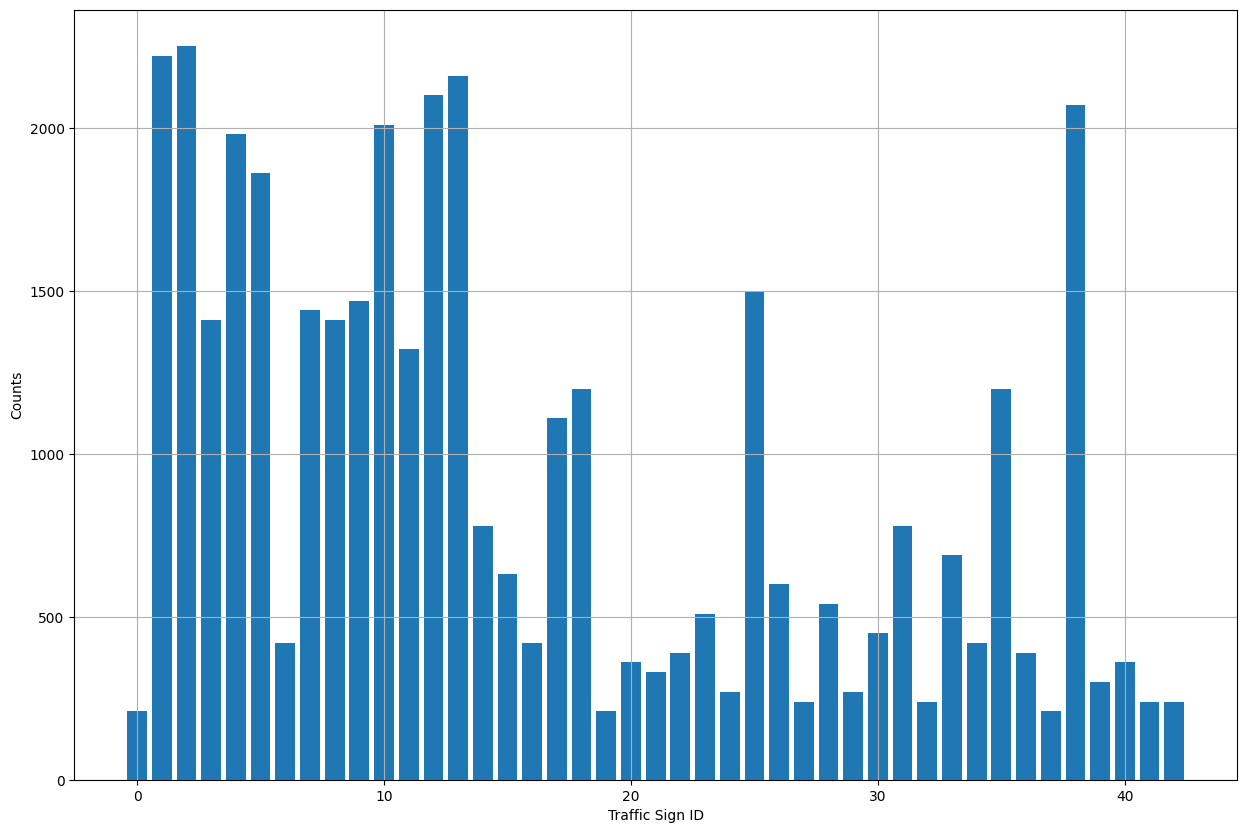

In [4]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

**Do you consider the dataset to be balanced? If so, why? If not, why?**

Нет, датасет не сбалансирован. По гистограмме видно, что количество изображений сильно отличается от класса к классу — некоторые классы содержат значительно больше примеров, чем другие.

**Are there any classes that are (significantly) over-represented or under-represented?**

Да, есть классы с очень большим количеством примеров (over-represented) и классы с малым количеством (under-represented). Это может привести к тому, что модель будет лучше распознавать часто встречающиеся знаки и хуже — редкие.

### Optional

Дополнительный анализ датасета: распределение разрешений и яркости по классам.

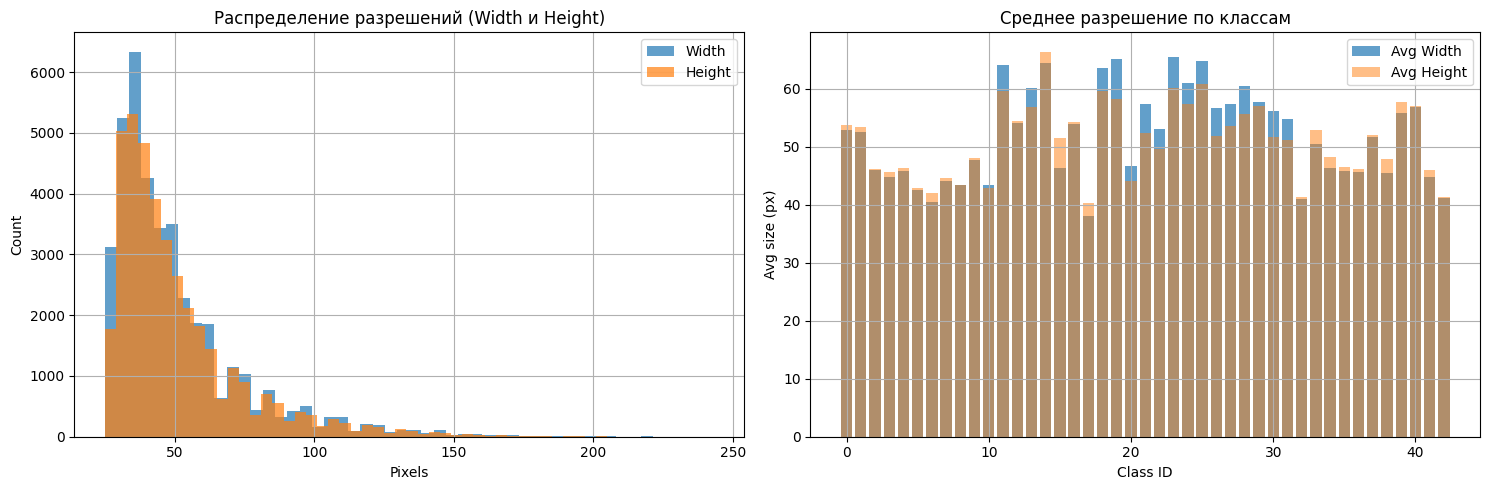

Мин. размер: 25x25
Макс. размер: 243x225
Средний размер: 51x50


In [5]:
# Анализ разрешений изображений
widths = data['Width'].values
heights = data['Height'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(widths, bins=50, alpha=0.7, label='Width')
ax1.hist(heights, bins=50, alpha=0.7, label='Height')
ax1.set_xlabel('Pixels'), ax1.set_ylabel('Count')
ax1.set_title('Распределение разрешений (Width и Height)')
ax1.legend(), ax1.grid(True)

# Среднее разрешение по классам
mean_size_per_class = data.groupby('ClassId')[['Width', 'Height']].mean()
ax2.bar(mean_size_per_class.index, mean_size_per_class['Width'], alpha=0.7, label='Avg Width')
ax2.bar(mean_size_per_class.index, mean_size_per_class['Height'], alpha=0.5, label='Avg Height')
ax2.set_xlabel('Class ID'), ax2.set_ylabel('Avg size (px)')
ax2.set_title('Среднее разрешение по классам')
ax2.legend(), ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Мин. размер: {widths.min()}x{heights.min()}')
print(f'Макс. размер: {widths.max()}x{heights.max()}')
print(f'Средний размер: {widths.mean():.0f}x{heights.mean():.0f}')

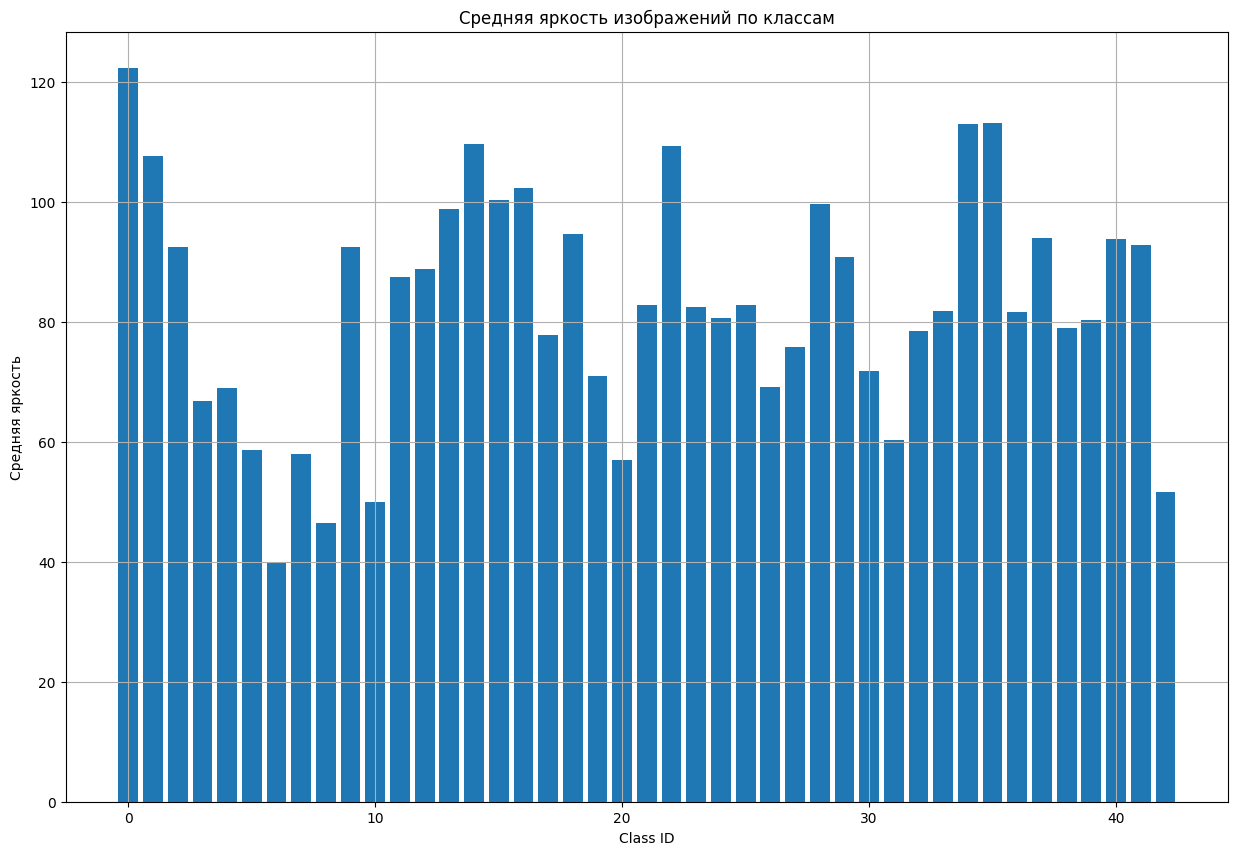

Самый яркий класс: 0 (яркость 122.2)
Самый тёмный класс: 6 (яркость 39.8)


In [6]:
# Анализ яркости по классам
from collections import defaultdict

brightness_per_class = defaultdict(list)

for idx in range(num_samples):
    row = data.iloc[idx]
    img = cv2.imread(os.path.join(root, row['Path']), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        brightness_per_class[row['ClassId']].append(np.mean(img))

# Средняя яркость по классам
class_ids = sorted(brightness_per_class.keys())
avg_brightness = [np.mean(brightness_per_class[c]) for c in class_ids]

plt.bar(class_ids, avg_brightness)
plt.xlabel('Class ID'), plt.ylabel('Средняя яркость')
plt.title('Средняя яркость изображений по классам')
plt.grid(True)
plt.show()

brightest = class_ids[np.argmax(avg_brightness)]
darkest = class_ids[np.argmin(avg_brightness)]
print(f'Самый яркий класс: {brightest} (яркость {max(avg_brightness):.1f})')
print(f'Самый тёмный класс: {darkest} (яркость {min(avg_brightness):.1f})')

### Выводы по опциональной части

**Разрешение:** изображения в датасете имеют разное разрешение, в отличие от MNIST или CIFAR10 где все картинки одного размера. Это значит, что перед обучением нужно будет привести все изображения к одному размеру (resize).

**Яркость:** средняя яркость отличается между классами. Некоторые классы значительно ярче или темнее других, что может быть связано с цветом самого знака (например, жёлтые знаки ярче тёмно-синих).